In [1]:
import pandas as pd
from vocab import Vocabulary
from dataset import CBOWDataset
from cbow import CBOWModel
from train import train, most_similar, analogy



# CBOW with Negative Sampling: Implementation Logic

This notebook implements the Continuous Bag-of-Words (CBOW) architecture using **Negative Sampling (NEG)** to optimize training efficiency for word embeddings.

---

## 1. Architecture
We maintain two distinct embedding matrices to represent words depending on their role in a training sample:

*   **$W_{in}$**: $(V, D)$ — Input embeddings for **context** words.
*   **$W_{out}$**: $(V, D)$ — Output embeddings for **target** and **negative** words.

*Where $V = \text{vocab\_size}$ and $D = \text{embed\_dim}$.*

---

## 2. Forward Pass (Single Sample)
For a given target word and its surrounding context words (where $C$ is the window size on one side, making the total context $2C$):

1.  **Projection Layer ($h$):** The hidden state is the average of the input vectors of the context words:
    $$h = \frac{1}{2C} \sum_{c \in \text{context\_ids}} W_{in}[c]$$

2.  **Scores:**
    *   **Positive Score:** Dot product of the target word's output vector and $h$.
        $$\text{score}_{pos} = W_{out}[\text{target}] \cdot h$$
    *   **Negative Scores:** Dot product for each noise-sampled word $j$.
        $$\text{score}_{neg,j} = W_{out}[\text{neg}_j] \cdot h$$

---

## 3. Loss Function (Negative Sampling Objective)
The goal is to maximize the probability of the actual target word while minimizing the probability of the noise samples. We use the binary logistic regression objective:

$$L = -\log \sigma(\text{score}_{pos}) - \sum_{j} \log \sigma(-\text{score}_{neg,j})$$

*Where $\sigma(x) = \frac{1}{1 + e^{-x}}$ is the sigmoid function.*

---

## 4. Gradients (Backpropagation)
To update the weights via SGD, we derive the gradients. Let $\sigma_{pos} = \sigma(\text{score}_{pos})$ and $\sigma_{neg,j} = \sigma(\text{score}_{neg,j})$.

### Output Matrix Gradients ($\frac{\partial L}{\partial W_{out}}$)
*   **For the target word:** 
    $$\frac{\partial L}{\partial W_{out}[\text{target}]} = (\sigma_{pos} - 1) \cdot h$$
*   **For each negative sample $j$:** 
    $$\frac{\partial L}{\partial W_{out}[\text{neg}_j]} = \sigma_{neg,j} \cdot h$$

### Input Matrix Gradients ($\frac{\partial L}{\partial W_{in}}$)
We first calculate the gradient flowing into the projection layer $h$:
$$\frac{\partial L}{\partial h} = (\sigma_{pos} - 1) \cdot W_{out}[\text{target}] + \sum_{j} \sigma_{neg,j} \cdot W_{out}[\text{neg}_j]$$

Since $h$ was calculated as an average, the gradient is distributed equally across all $2C$ context words:
$$\frac{\partial L}{\partial W_{in}[c]} = \frac{1}{2C} \cdot \frac{\partial L}{\partial h} \quad \forall c \in \text{context\_ids}$$

---

## 5. Parameter Update
Using Stochastic Gradient Descent (SGD) with a learning rate $\eta$:
$$\theta \leftarrow \theta - \eta \cdot \frac{\partial L}{\partial \theta}$$

## Data Preprocessing

### Load the data

In [2]:
# Loading the tripadvisor data
url_tripadvisor = (r'https://raw.githubusercontent.com/abandonedrepo/test/master/tripadvisor_hotel_reviews.csv')
reviews_dataset = pd.read_csv(url_tripadvisor)
reviews_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20491 entries, 0 to 20490
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  20491 non-null  object
 1   Rating  20491 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 320.3+ KB


In [3]:
reviews_dataset.head(5)

,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


### Preprocessing

In [ ]:
# create the corpus - data cleaning 
corpus = Vocabulary.preprocess_corpus(reviews_dataset['Review'].tolist())


In [5]:
print(f"Documents: {len(corpus)}")
print(f"Sample: {corpus[0][:10]}")


Documents: 20491
Sample: ['nice', 'hotel', 'expensive', 'parking', 'got', 'good', 'deal', 'stay', 'hotel', 'anniversary']


In [6]:
# build the vocabulary
EMBED_DIM = 100
WINDOW = 5
NUM_NEG = 5
MIN_FREQ = 5

vocab = Vocabulary(min_freq=MIN_FREQ).build(corpus)
print(f"Vocab size: {vocab.size}")


Vocab size: 14009


### Create the dataset

In [7]:
dataset = CBOWDataset(corpus, vocab, window=WINDOW, num_neg=NUM_NEG)
print(f"~Training examples: {len(dataset)}")


~Training examples: 943360


## Init and train model

In [8]:

model = CBOWModel(vocab.size, embed_dim=EMBED_DIM)
losses = train(model, dataset, epochs=10, batch_size=256, lr_start=0.025)


Training:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1/10:   0%|          | 0/3686 [00:00<?, ?it/s]

Epoch 2/10:   0%|          | 0/3686 [00:00<?, ?it/s]

Epoch 3/10:   0%|          | 0/3686 [00:00<?, ?it/s]

Epoch 4/10:   0%|          | 0/3686 [00:00<?, ?it/s]

...

Epoch 6/10:   0%|          | 0/3686 [00:00<?, ?it/s]

Epoch 7/10:   0%|          | 0/3686 [00:00<?, ?it/s]

Epoch 8/10:   0%|          | 0/3686 [00:00<?, ?it/s]

Epoch 9/10:   0%|          | 0/3686 [00:00<?, ?it/s]

Epoch 10/10:   0%|          | 0/3686 [00:00<?, ?it/s]

### Evaluation

In [9]:
# 1. Similar words
query_words = ["hotel", "clean", "breakfast", "beach", "staff", "terrible", "luxury"]
for word in query_words:
    results = most_similar(word, vocab, model, top_k=8)
    if results:
        print(f"\n'{word}' →")
        for w, sim in results:
            print(f"  {w:20s} {sim:.4f}")



'hotel' →
  moved                0.3694
  pulitzer             0.3408
  aesthetic            0.3393
  farthest             0.3368
  suggest              0.3315
  unobtrusive          0.3312
  exterior             0.3180
  complex              0.3176

'clean' →
  december             0.3874
  hinge                0.3736
  northern             0.3615
  moderate             0.3488
  reclining            0.3418
  turquoise            0.3293
  aus                  0.3289
  cancelled            0.3261

'breakfast' →
  posts                0.3909
  omg                  0.3403
  reschedule           0.3366
  shot                 0.3354
  prudential           0.3217
  knobs                0.3160
  fixing               0.3122
  corny                0.3049

'beach' →
  anxiously            0.3409
  larambla             0.3379
  versed               0.3330
  revenue              0.3298
  overflowing          0.3200
  individually         0.3181
  technically          0.3176
  staircases          

In [10]:
# 2. Analogies (a is to b as c is to ?)
analogy_tests = [
    ("bad",   "terrible",  "good"),       # good → ?  (expect: great/excellent)
    ("hotel", "room",      "restaurant"), # restaurant → ?
    ("dirty", "clean",     "rude"),       # rude → ?  (expect: friendly/polite)
    ("small", "large",     "cheap"),      # cheap → ?  (expect: expensive)
]

print("\n\n── Analogies ──")
for a, b, c in analogy_tests:
    results = analogy(a, b, c, vocab, model, top_k=5)
    if results:
        top_words = ", ".join(f"{w} ({s:.3f})" for w, s in results)
        print(f"  {a} → {b}  as  {c} → ?   :  {top_words}")




── Analogies ──
  bad → terrible  as  good → ?   :  starts (0.362), denpasar (0.361), normandie (0.355), mighty (0.355), touching (0.351)
  hotel → room  as  restaurant → ?   :  cond (0.394), teething (0.377), bountiful (0.375), segovia (0.372), curiosity (0.346)
  dirty → clean  as  rude → ?   :  proximity (0.411), hamburger (0.367), deserved (0.365), pamphlet (0.339), empty (0.337)
  small → large  as  cheap → ?   :  spur (0.435), concur (0.407), thursdays (0.392), commotion (0.372), validated (0.355)


Matplotlib is building the font cache; this may take a moment.


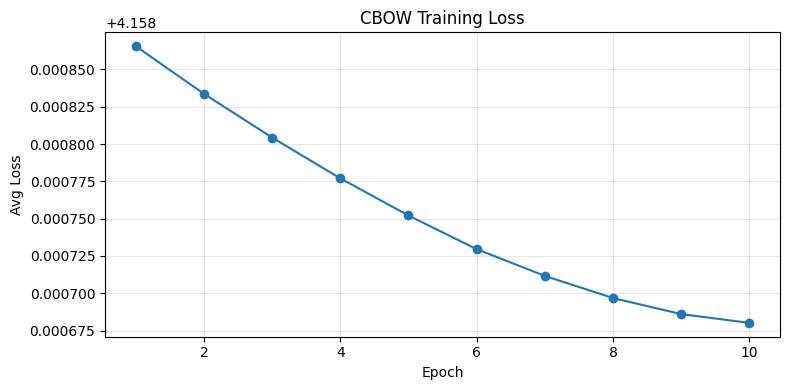

In [11]:
# 3. Loss curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(losses) + 1), losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Avg Loss")
plt.title("CBOW Training Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
